# Climara insights for Bayer — community signal brief

Reads the exported data product (`/out/<run_id>/*.parquet`). Nothing here calls a model;
every number traces to a `run_id` in `manifest.json`.

**Grains:** `documents` → `mentions` → `user_profiles` / `switch_events` / `treatment_summary`.

Two rules this notebook applies everywhere, both of which change the numbers materially:

- **`experienced_by == 'self'`** — replies are ~80% of the corpus and members constantly discuss
  *each other's* treatments. Without this filter every replier discussing the original poster's
  Climara is counted as a Climara patient.
- **`superseded == False`** — a member who says "Climara", "the patch" and "HRT" is describing
  one therapy three ways. Umbrella entities are flagged, not deleted.


In [1]:
import json, pathlib, textwrap
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

OUT = pathlib.Path('/out')
# Run directories are timestamped, so the newest sorts last. No 'latest' symlink
# to go stale or behave differently on another platform.
RUN = max(OUT.glob('2*Z'))
manifest = json.loads((RUN/'manifest.json').read_text())

load = lambda name: pd.read_parquet(RUN/f'{name}.parquet')
documents  = load('documents')
mentions   = load('mentions')
switches   = load('switch_events')
profiles   = load('user_profiles')
summary    = load('treatment_summary')

for c in ['current_treatments','past_treatments','considering_treatments','rejected_treatments','symptoms']:
    profiles[c] = profiles[c].map(lambda v: json.loads(v) if isinstance(v, str) else (v or []))

print(f"run {manifest['run_id']} · model {manifest['model']} · prompt {manifest['prompt_version']} · lexicon {manifest['lexicon_digest']}")
print(manifest['row_counts'])


run 20260917T205525Z · model llama3.1:8b · prompt v7 · lexicon 74b9f4261eee
{'documents': 9991, 'mentions': 36554, 'switch_events': 405, 'demographic_claims': 5462, 'user_profiles': 100, 'treatment_summary': 76}


## Palette

Validated categorical slots (CVD-safe adjacent pairs). Colour follows the *entity*, never its rank.


In [2]:
C1, C2 = '#2a78d6', '#eb6834'        # categorical slots 1-2

# Colour by the job it does, not by taste.
#   categorical -> identity  (C1/C2, fixed order, never cycled)
#   sequential  -> magnitude (one hue, light->dark)
#   diverging   -> polarity  (two hues + a NEUTRAL grey midpoint)
# All validated: worst adjacent CVD dE 24.7 / 21.6, normal-vision 33.6 / 32.3.
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
DIV_NEG, DIV_MID, DIV_POS = '#e34948', '#f0efec', '#2a78d6'
SEQ = LinearSegmentedColormap.from_list('seq_blue', ['#eef4fd', '#9ec5f4', '#3987e5', '#184f95'])
DIV = LinearSegmentedColormap.from_list('div_br', [DIV_NEG, DIV_MID, DIV_POS])
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#8a8984'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'axes.edgecolor': '#d8d7d2', 'axes.labelcolor': INK2,
    'text.color': INK, 'xtick.color': INK2, 'ytick.color': INK2,
    'axes.grid': True, 'grid.color': '#e8e7e2', 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'figure.dpi': 120,
})

def tidy(ax, title, sub=None):
    # pad has to clear the subtitle or the two overlap - at pad=14 they collided
    # on every chart in this notebook.
    ax.set_title(title, color=INK, fontsize=12, pad=26 if sub else 8, loc='left')
    if sub:
        ax.text(0, 1.015, sub, transform=ax.transAxes, color=MUTED, fontsize=9, va='bottom')
    ax.set_axisbelow(True)
    return ax


## 1. Corpus and coverage

State the denominator first. Everything downstream is a share of this.


In [3]:
self_tx = mentions[(mentions.kind=='treatment') & (mentions.experienced_by=='self')]
extracted_docs = mentions.doc_id.nunique()

print(f'documents in corpus      {len(documents):>6,}')
print(f'documents extracted      {extracted_docs:>6,}   ({100*extracted_docs/len(documents):.1f}%)')
print(f'members                  {documents.author_id.nunique():>6,}')
print(f'mentions                 {len(mentions):>6,}   ({mentions.canonical_id.notna().mean()*100:.1f}% mapped)')
print(f'  treatment, self        {len(self_tx):>6,}')
print(f'switch edges             {len(switches):>6,}')
print(f'mentions with context    {mentions.context.notna().mean()*100:>5.1f}%')

if extracted_docs < len(documents):
    print(f'\n*** PARTIAL RUN: {extracted_docs} of {len(documents)} documents. ***')
    print('*** Counts below are a sample, not the full community. Run `make extract` for all. ***')


documents in corpus       9,991
documents extracted       9,754   (97.6%)
members                     100
mentions                 36,554   (88.5% mapped)
  treatment, self        10,689
switch edges                405
mentions with context     98.5%

*** PARTIAL RUN: 9754 of 9991 documents. ***
*** Counts below are a sample, not the full community. Run `make extract` for all. ***


## 2. Who is the Climara patient?

**The cohort cut is derived, not chosen.** "Any self-attributed mention" counts
everyone who ever *discussed* the drug — 84 of 100 members, which is not a patient
cohort. Two independent one-dimensional thresholding methods are run over the
per-member mention counts:

- **largest gap** — the biggest jump between consecutive sorted counts
- **Otsu** — the cut maximising between-class variance

When a real cohort exists these pick the **identical member set**; when one doesn't,
they diverge. Agreement is the evidence, and disagreement is a finding rather than
a number to force.

any self-attributed mention : 81 members
largest-gap cut  >=  29.0   -> 7 members
Otsu cut         >=  49.0   -> 7 members
methods AGREE - the cohort is real  ->  cohort = 7 of 100 members


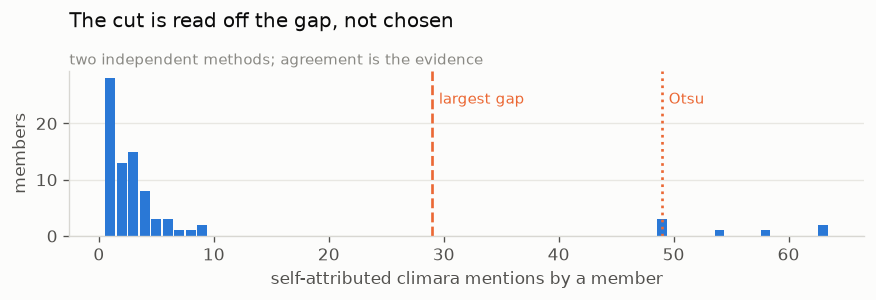

In [4]:
import numpy as np

def derive_cohort(canonical_id, frame=None):
    """Two independent thresholds over per-member mention counts.

    Returns (members, gap_cut, otsu_cut, agree). `agree` True means both methods
    selected the same people - the evidence that a distinct cohort exists at all.
    """
    src = frame if frame is not None else self_tx
    counts = src[src.canonical_id == canonical_id].groupby('author_id').size() \
                .sort_values(ascending=False)
    if len(counts) < 4:
        return set(counts.index), None, None, False
    v = counts.values.astype(float)

    gaps = v[:-1] - v[1:]
    i = int(np.argmax(gaps))
    gap_cut = (v[i] + v[i + 1]) / 2

    best, otsu_cut = -1.0, v.min()
    for t in np.unique(v):                      # between-class variance, 1-D Otsu
        hi, lo = v[v >= t], v[v < t]
        if not len(hi) or not len(lo):
            continue
        w = len(hi) * len(lo) * (hi.mean() - lo.mean()) ** 2
        if w > best:
            best, otsu_cut = w, t

    by_gap  = set(counts[counts >= gap_cut].index)
    by_otsu = set(counts[counts >= otsu_cut].index)
    agree = bool(by_gap) and by_gap == by_otsu
    return (by_gap if agree else by_gap), gap_cut, otsu_cut, agree


ENTITY = 'climara'
climara, GAP_CUT, OTSU_CUT, AGREE = derive_cohort(ENTITY)
counts = self_tx[self_tx.canonical_id == ENTITY].groupby('author_id').size()

print(f"any self-attributed mention : {len(counts)} members")
print(f"largest-gap cut  >= {GAP_CUT:>5.1f}   -> {(counts >= GAP_CUT).sum()} members")
print(f"Otsu cut         >= {OTSU_CUT:>5.1f}   -> {(counts >= OTSU_CUT).sum()} members")
print(f"methods {'AGREE - the cohort is real' if AGREE else 'DISAGREE - no distinct cohort'}"
      f"  ->  cohort = {len(climara)} of {len(profiles)} members")

dist = counts.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7.4, 2.6))
ax.bar(dist.index, dist.values, color=C1, width=0.85)
for cut, style, lab in ((GAP_CUT, '--', 'largest gap'), (OTSU_CUT, ':', 'Otsu')):
    ax.axvline(cut, color=C2, lw=1.6, ls=style)
    ax.annotate(lab, xy=(cut, ax.get_ylim()[1] * 0.8), xytext=(4, 0),
                textcoords='offset points', color=C2, fontsize=9)
ax.set_xlabel(f'self-attributed {ENTITY} mentions by a member')
ax.set_ylabel('members')
ax.grid(axis='x', visible=False)
tidy(ax, 'The cut is read off the gap, not chosen',
     'two independent methods; agreement is the evidence')
plt.tight_layout(); plt.show()

cp   = profiles[profiles.author_id.isin(climara)]
rest = profiles[~profiles.author_id.isin(climara)]

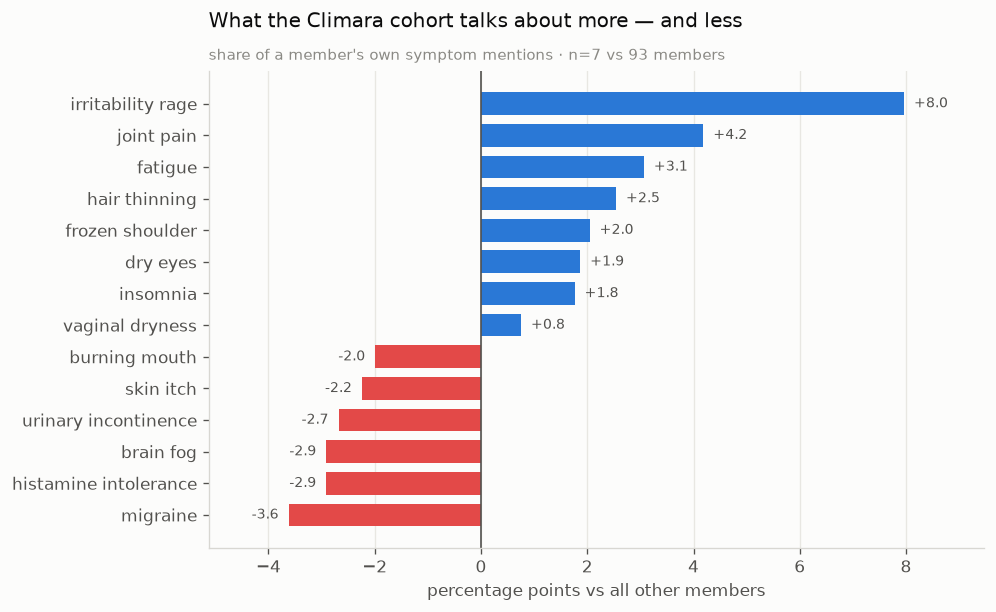

In [5]:
# Symptom mix, Climara cohort vs everyone else.
#
# FIXED: the previous version plotted "share of members who ever mention X",
# which SATURATES - across ~100 documents per member every top symptom hits 100%
# in both groups and the chart says nothing. It also omitted the `supported`
# filter used everywhere else, and set the x-axis tick count from the cohort
# threshold.
#
# Share of a member's own symptom mentions discriminates, and is a fair
# comparison because it normalises for how much each member posts.
sym = mentions[(mentions.kind == 'symptom') & (mentions.experienced_by == 'self')
               & mentions.supported & mentions.canonical_id.notna()]

def symptom_mix(members):
    s = sym[sym.author_id.isin(members)]
    per = s.groupby(['author_id', 'canonical_id']).size().unstack(fill_value=0)
    return per.div(per.sum(axis=1), axis=0).mean()      # mean mix across members

idx  = sorted(sym.canonical_id.unique())
a    = symptom_mix(climara).reindex(idx).fillna(0)
b    = symptom_mix(set(rest.author_id)).reindex(idx).fillna(0)
diff = (a - b).sort_values()
show = pd.concat([diff.head(6), diff.tail(8)])          # both poles

# Polarity -> diverging. Position relative to zero carries the sign too, so
# identity is never colour-alone.
fig, ax = plt.subplots(figsize=(8.4, 5.2))
ax.barh(range(len(show)), show.values * 100,
        color=[DIV_POS if v > 0 else DIV_NEG for v in show.values], height=0.72)
ax.axvline(0, color=INK2, lw=1)
ax.margins(x=0.13)          # room for the end labels
ax.set_yticks(range(len(show)))
ax.set_yticklabels([s.replace('_', ' ') for s in show.index])
ax.set_xlabel('percentage points vs all other members')
ax.grid(axis='y', visible=False)
for i, v in enumerate(show.values * 100):               # selective direct labels
    ax.annotate(f'{v:+.1f}', xy=(v, i), xytext=(6 if v > 0 else -6, 0),
                textcoords='offset points', va='center',
                ha='left' if v > 0 else 'right', color=INK2, fontsize=8.5)
tidy(ax, 'What the Climara cohort talks about more — and less',
     f'share of a member\'s own symptom mentions · n={len(climara)} vs {len(rest)} members')
plt.tight_layout(); plt.show()

### Symptom mix by treatment

**Rebuilt.** The first version grouped by "every member who ever self-mentioned the
treatment" — which is 69–100 of 100 members for anything common, so every row was
just the population average and the matrix showed nothing.

Two changes make it informative: rows are the **derived cohort** for each treatment
(same dual-method threshold as the Climara cut, so only treatments with a genuinely
distinct user group appear), and cells show **deviation from the all-member mean**
rather than the raw share. That is polarity, so the colour is **diverging** with a
neutral midpoint — grey means "same as everyone else".

21 treatments have a cohort both methods agree on:
   minoxidil                n=12
   estrogel                 n=11
   collagen                 n=11
   vagifem                  n=8
   climara                  n=7
   testosterone             n=7
   imvexxy                  n=7
   red_clover               n=7
   lab_testing              n=6
   dose_change              n=6
   estring                  n=6
   l_theanine               n=6
   activelle                n=5
   antihistamine            n=5
   vitamin_d                n=5
   dao_enzyme               n=4
   creatine                 n=4
   divigel                  n=3
   cbt                      n=3
   iron                     n=3
   ssri_snri                n=3


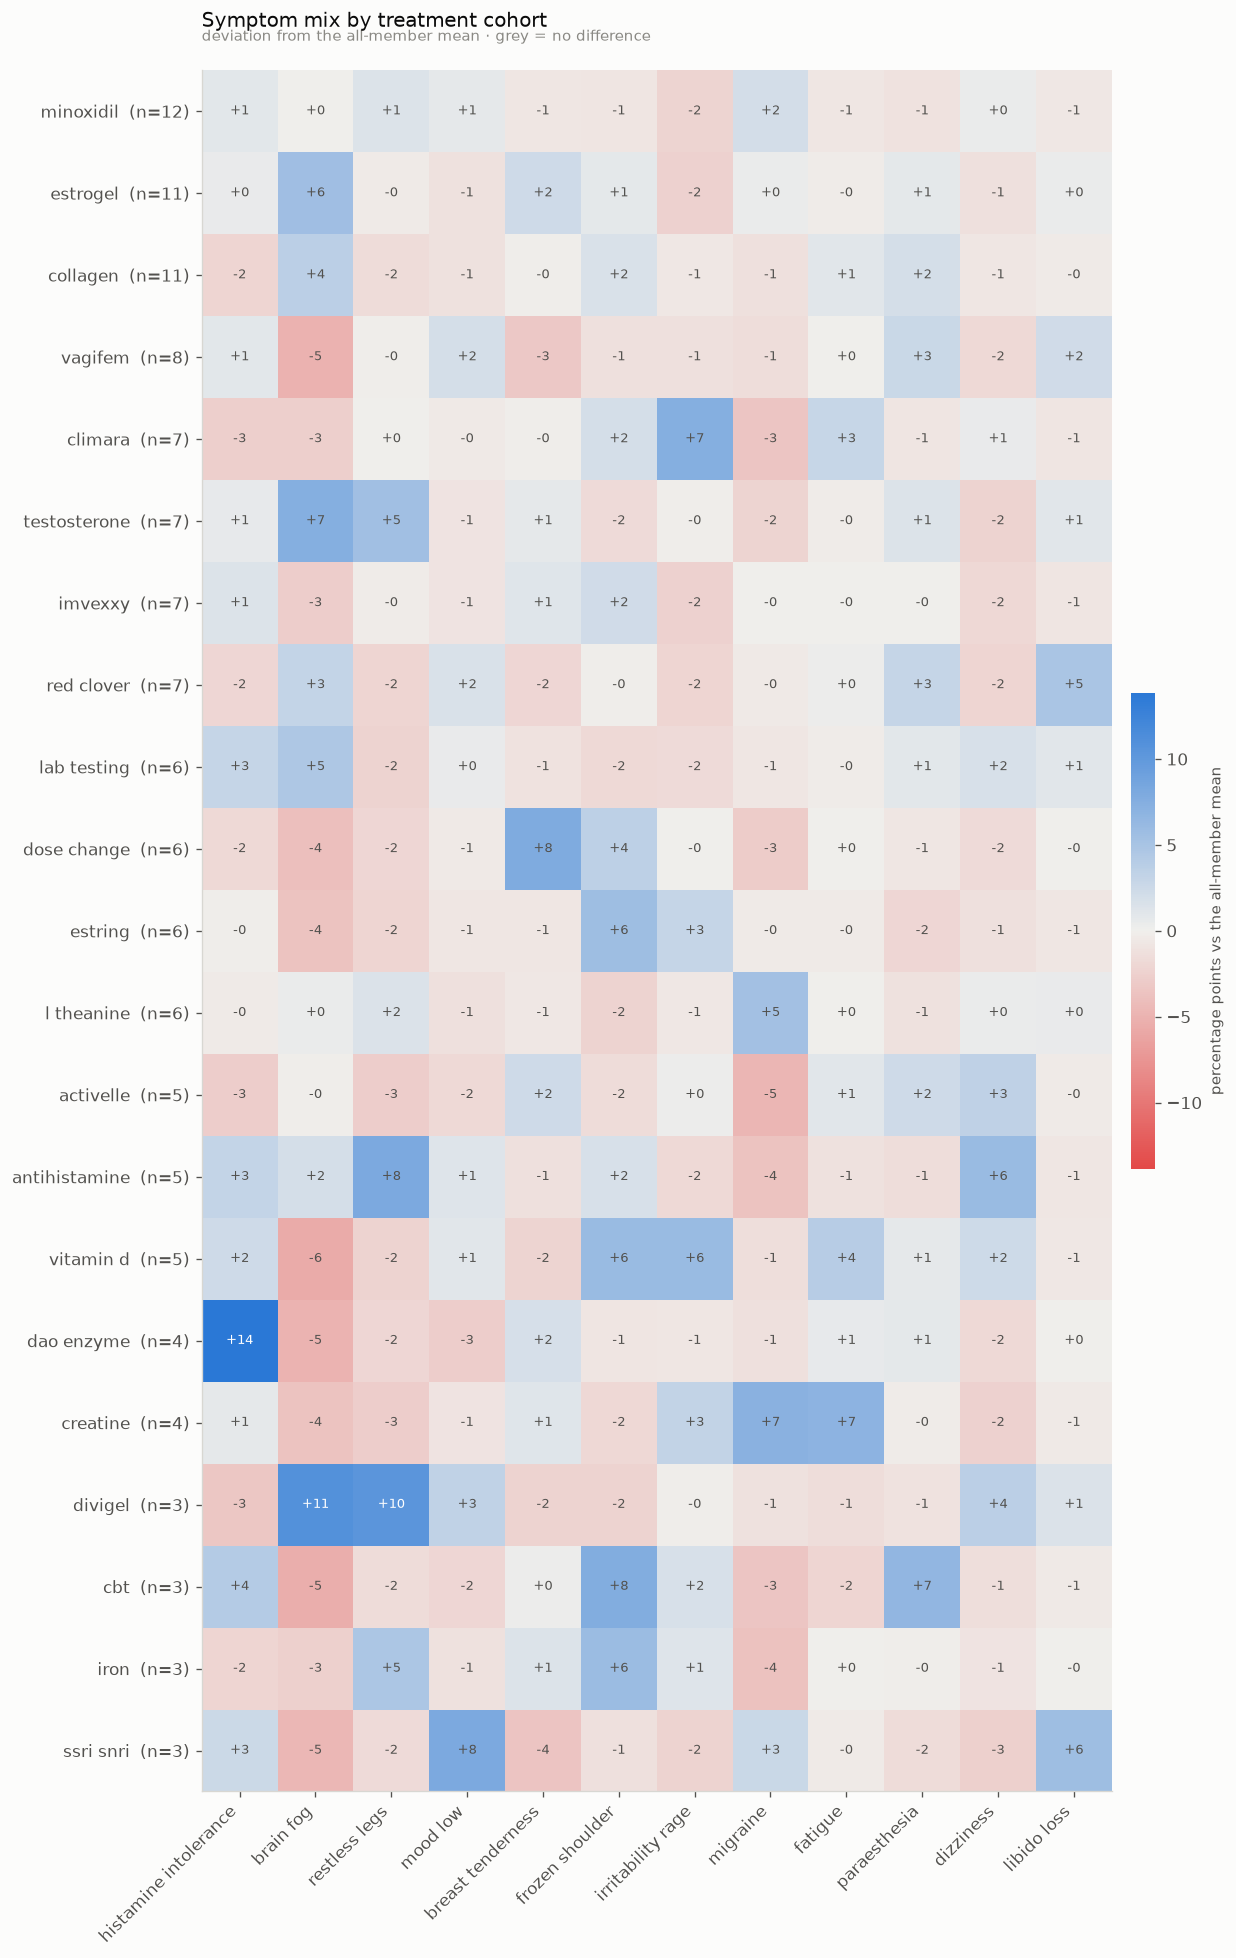

In [6]:
baseline = symptom_mix(set(mentions.author_id.unique()))

cohorts = {}
for ent in self_tx.canonical_id.dropna().unique():
    if ent == 'non_entity':
        continue
    mem, gap, otsu, agree = derive_cohort(ent)
    if agree and len(mem) >= 3:                 # a real, non-trivial user group
        cohorts[ent] = mem

print(f'{len(cohorts)} treatments have a cohort both methods agree on:')
for e, m in sorted(cohorts.items(), key=lambda kv: -len(kv[1])):
    print(f'   {e:24} n={len(m)}')

if cohorts:
    idx = sorted(sym.canonical_id.unique())
    rows = {f'{e.replace("_", " ")}  (n={len(m)})':
            (symptom_mix(m).reindex(idx).fillna(0) - baseline.reindex(idx).fillna(0))
            for e, m in sorted(cohorts.items(), key=lambda kv: -len(kv[1]))}
    mat = pd.DataFrame(rows).T
    mat = mat[mat.abs().max().sort_values(ascending=False).head(12).index]

    lim = float(mat.abs().max().max()) * 100
    fig, ax = plt.subplots(figsize=(10.4, 0.62 * len(mat) + 3.4))
    im = ax.imshow(mat.values * 100, cmap=DIV, aspect='auto', vmin=-lim, vmax=lim)
    ax.set_xticks(range(mat.shape[1]))
    ax.set_xticklabels([c.replace('_', ' ') for c in mat.columns], rotation=45, ha='right')
    ax.set_yticks(range(mat.shape[0])); ax.set_yticklabels(mat.index)
    ax.grid(False)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.values[i, j] * 100
            ax.annotate(f'{v:+.0f}', (j, i), ha='center', va='center', fontsize=7.5,
                        color='white' if abs(v) > lim * 0.6 else INK2)
    cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cb.set_label('percentage points vs the all-member mean', color=INK2, fontsize=9)
    cb.outline.set_visible(False)
    tidy(ax, 'Symptom mix by treatment cohort',
         'deviation from the all-member mean · grey = no difference')
    plt.tight_layout(); plt.show()
else:
    print('No treatment has a cohort both methods agree on - nothing to plot.')

### Sentiment by treatment

Two views, because they answer different questions and one chart cannot do both.
The **matrix** is magnitude — how each treatment's mentions distribute across
sentiment labels. The **bar** is polarity — net sentiment, positive share minus
negative share, which is the number you would actually quote.

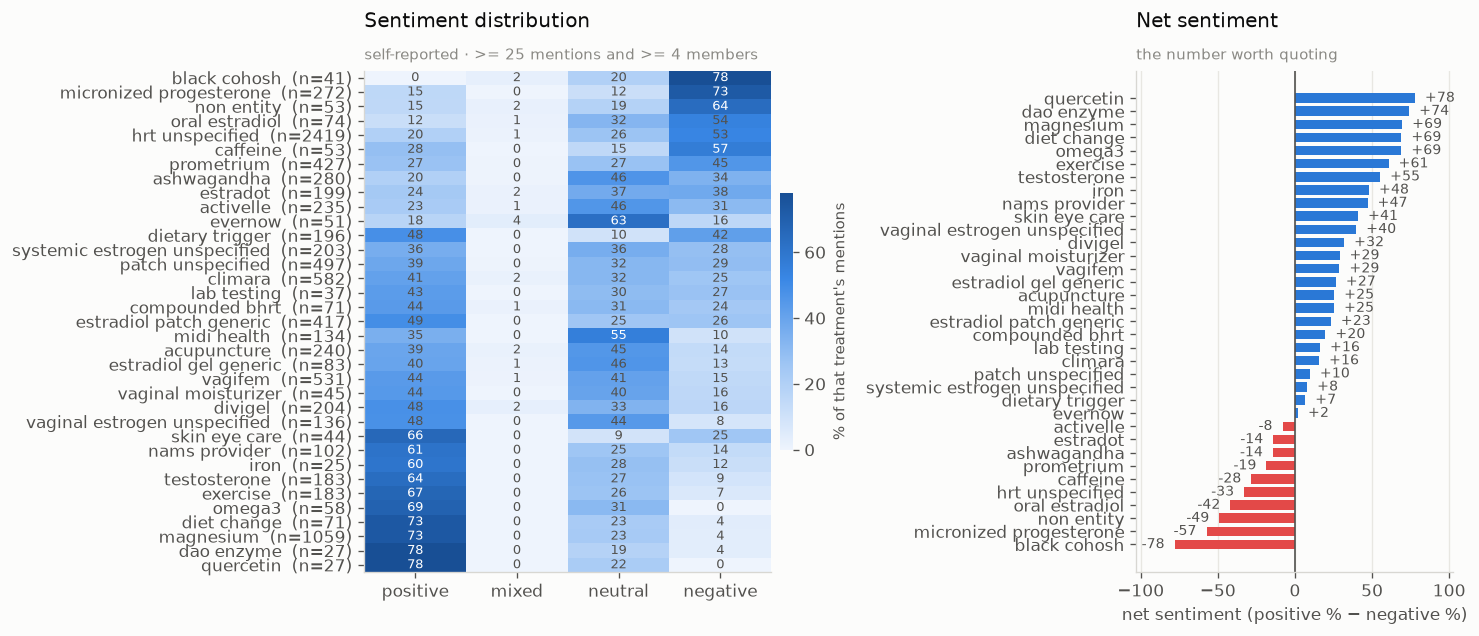

climara: net +16pp  (positive 41% / negative 25%)  n=582


In [7]:
sent = self_tx[self_tx.sentiment.notna() & self_tx.canonical_id.notna()]
# A rate needs enough mentions AND enough independent people. Nothing currently
# fails the member floor, but a mention floor alone would let one prolific member
# define a treatment's sentiment.
MIN_MENTIONS, MIN_MEMBERS = 25, 4
g = sent.groupby('canonical_id').agg(n=('sentiment', 'size'), members=('author_id', 'nunique'))
keep = g[(g.n >= MIN_MENTIONS) & (g.members >= MIN_MEMBERS)].index
sent = sent[sent.canonical_id.isin(keep)]

ORDER = ['positive', 'mixed', 'neutral', 'negative']
tab = (sent.groupby(['canonical_id', 'sentiment']).size().unstack(fill_value=0)
          .reindex(columns=ORDER, fill_value=0))
share = tab.div(tab.sum(axis=1), axis=0)
net = (share['positive'] - share['negative']).sort_values()
share = share.loc[net.index]

fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.4), gridspec_kw={'width_ratios': [1.35, 1]})

ax = axes[0]
im = ax.imshow(share.values * 100, cmap=SEQ, aspect='auto', vmin=0)
ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER)
ax.set_yticks(range(share.shape[0]))
ax.set_yticklabels([f'{i.replace("_", " ")}  (n={tab.loc[i].sum()})' for i in share.index])
ax.grid(False)
for i in range(share.shape[0]):
    for j in range(share.shape[1]):
        v = share.values[i, j] * 100
        ax.annotate(f'{v:.0f}', (j, i), ha='center', va='center', fontsize=8,
                    color='white' if v > 55 else INK2)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cb.set_label('% of that treatment\'s mentions', color=INK2, fontsize=9)
cb.outline.set_visible(False)
tidy(ax, 'Sentiment distribution', f'self-reported · >= {MIN_MENTIONS} mentions and >= {MIN_MEMBERS} members')

ax = axes[1]
ax.barh(range(len(net)), net.values * 100,
        color=[DIV_POS if v > 0 else DIV_NEG for v in net.values], height=0.72)
ax.axvline(0, color=INK2, lw=1)
ax.margins(x=0.16)          # room for the end labels
ax.set_yticks(range(len(net)))
ax.set_yticklabels([i.replace('_', ' ') for i in net.index])
ax.set_xlabel('net sentiment (positive % − negative %)')
ax.grid(axis='y', visible=False)
for i, v in enumerate(net.values * 100):
    ax.annotate(f'{v:+.0f}', xy=(v, i), xytext=(6 if v > 0 else -6, 0),
                textcoords='offset points', va='center',
                ha='left' if v > 0 else 'right', color=INK2, fontsize=8.5)
tidy(ax, 'Net sentiment', 'the number worth quoting')
plt.tight_layout(); plt.show()

CL = 'climara'
if CL in net.index:
    print(f"{CL}: net {net[CL]*100:+.0f}pp  "
          f"(positive {share.loc[CL,'positive']*100:.0f}% / "
          f"negative {share.loc[CL,'negative']*100:.0f}%)  n={tab.loc[CL].sum()}")

## 3. What are members saying about Climara?

Stance is the LATEST mention per member — "I'm on Climara" in November and "I came off it"
in March resolves to `past`, not `current`.


81 members with a self-attributed Climara mention; stance counted ONCE each, at their latest mention
stance
current        39.0
past           22.0
considering     6.0
rejected       11.0
recommended     3.0
  sum = 81 = members   (the double-counting version summed to 131)


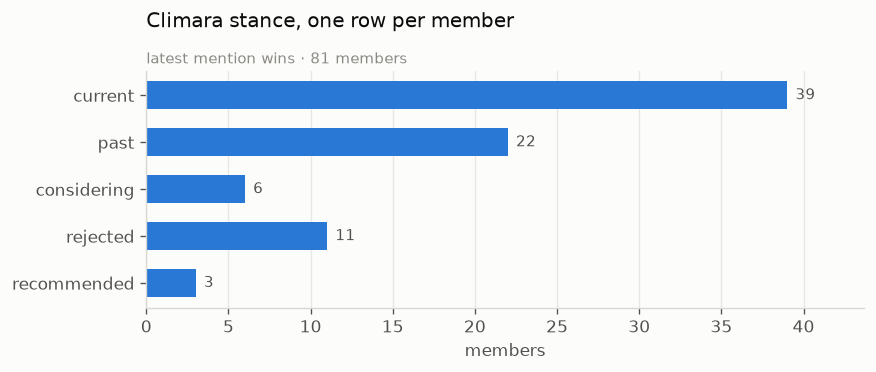

In [8]:
# FIXED: this was labelled "latest per member" but counted a member once per
# stance they ever expressed - the bars summed to 161 across 86 members, because
# 52 people appear in more than one. Someone who was "considering" in November and
# "current" in January is ONE current patient, not two data points.
cl = self_tx[self_tx.canonical_id == 'climara']

latest = (cl.sort_values('created_at').groupby('author_id')
            .agg(stance=('stance', 'last'), sentiment=('sentiment', 'last')))
order = ['current', 'past', 'considering', 'rejected', 'recommended',
         'warned_against', 'unclear']
counts = latest.stance.value_counts().reindex(order).dropna()

print(f'{len(latest)} members with a self-attributed Climara mention; '
      f'stance counted ONCE each, at their latest mention')
print(counts.to_string())
print(f'  sum = {int(counts.sum())} = members   (the double-counting version summed '
      f'to {cl.groupby("stance").author_id.nunique().sum()})')

fig, ax = plt.subplots(figsize=(7.4, 3.2))
ax.barh(counts.index[::-1], counts.values[::-1], color=C1, height=0.6)
ax.margins(x=0.12)
for i, v in enumerate(counts.values[::-1]):
    ax.annotate(str(int(v)), xy=(v, i), xytext=(5, 0), textcoords='offset points',
                va='center', color=INK2, fontsize=9)
ax.grid(axis='y', visible=False)
ax.set_xlabel('members')
tidy(ax, 'Climara stance, one row per member',
     f'latest mention wins · {len(latest)} members')
plt.tight_layout(); plt.show()

## 4. Switching — to and from Climara

**Direction is extracted, not inferred** — `"switched from Estradot to Climara"` and
`"switched from Climara"` are different rows, and keyword counting cannot tell them
apart.

Two series (onto / away from Climara), so a legend is present and the two are also
direct-labelled — identity is never colour-alone. Reasons are shown beside the bars
rather than encoded, because the counts are small enough that a reader wants the
actual words.

                   edges  members
onto climara          25       20
away from climara     46       29
49 of 71 edges carry a stated reason


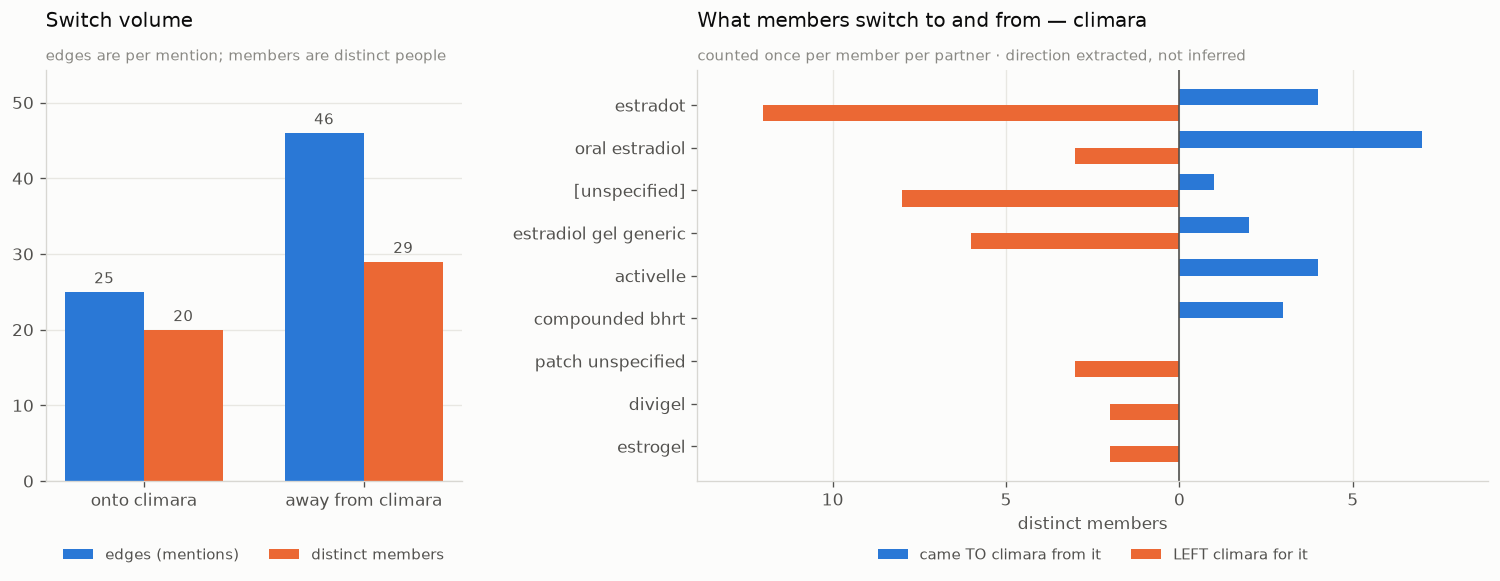

In [9]:
CL = 'climara'
sw = switches.copy()
sw['from_'] = sw.from_canonical.fillna('[' + sw.from_surface + ']')
sw['to_']   = sw.to_canonical.fillna('[' + sw.to_surface + ']')

onto = sw[(sw.to_canonical == CL) & (sw.from_canonical != CL)]
away = sw[(sw.from_canonical == CL) & (sw.to_canonical != CL)]

# Edges are per-MENTION: a member who retells their switch across several posts
# contributes several. Report both - they answer different questions ("how much is
# this talked about" vs "how many people did it").
tot = pd.DataFrame({'edges':   [len(onto), len(away)],
                    'members': [onto.author_id.nunique(), away.author_id.nunique()]},
                   index=[f'onto {CL}', f'away from {CL}'])
print(tot.to_string())
print(f"{sw[(sw.from_canonical==CL)|(sw.to_canonical==CL)].reason.notna().sum()} of "
      f"{len(onto)+len(away)} edges carry a stated reason")

fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.0),
                         gridspec_kw={'width_ratios': [1, 1.9]})

ax = axes[0]
x, w = np.arange(len(tot)), 0.36
ax.bar(x - w / 2, tot.edges,   width=w, color=C1, label='edges (mentions)')
ax.bar(x + w / 2, tot.members, width=w, color=C2, label='distinct members')
ax.set_xticks(x); ax.set_xticklabels(tot.index)
ax.grid(axis='x', visible=False); ax.margins(y=0.18)
for xi, (e, mem) in enumerate(zip(tot.edges, tot.members)):
    ax.annotate(str(e),   (xi - w / 2, e),   ha='center', va='bottom',
                xytext=(0, 3), textcoords='offset points', color=INK2, fontsize=9)
    ax.annotate(str(mem), (xi + w / 2, mem), ha='center', va='bottom',
                xytext=(0, 3), textcoords='offset points', color=INK2, fontsize=9)
ax.legend(frameon=False, labelcolor=INK2, fontsize=9,
          loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=2)
tidy(ax, 'Switch volume', 'edges are per mention; members are distinct people')

ax = axes[1]
def members_by(df, col):
    return (df.groupby(df[col].fillna('(unspecified)').str.replace('_', ' '))
              .author_id.nunique().sort_values(ascending=False).head(8))
a, b = members_by(onto, 'from_'), members_by(away, 'to_')
labels = sorted(set(a.index) | set(b.index),
                key=lambda k: -(a.get(k, 0) + b.get(k, 0)))[:9][::-1]
y, h = np.arange(len(labels)), 0.38
ax.barh(y + h / 2, [a.get(k, 0) for k in labels], height=h, color=C1,
        label=f'came TO {CL} from it')
ax.barh(y - h / 2, [-b.get(k, 0) for k in labels], height=h, color=C2,
        label=f'LEFT {CL} for it')
ax.axvline(0, color=INK2, lw=1)
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlabel('distinct members')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{abs(int(v))}'))
ax.grid(axis='y', visible=False); ax.margins(x=0.10)
# legend BELOW the axes - inside the plot it sat on top of the lower-right bars
ax.legend(frameon=False, labelcolor=INK2, fontsize=9,
          loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=2)
tidy(ax, f'What members switch to and from — {CL}',
     'counted once per member per partner · direction extracted, not inferred')
plt.tight_layout(); plt.show()

#### Why they move

The stated reasons, as charts rather than printed tables. Counted **per member**, so
one person repeating their story across posts does not stretch a bar. Reasons are
free text from the member, lightly folded into themes — the raw strings are printed
underneath so nothing is hidden behind the grouping.

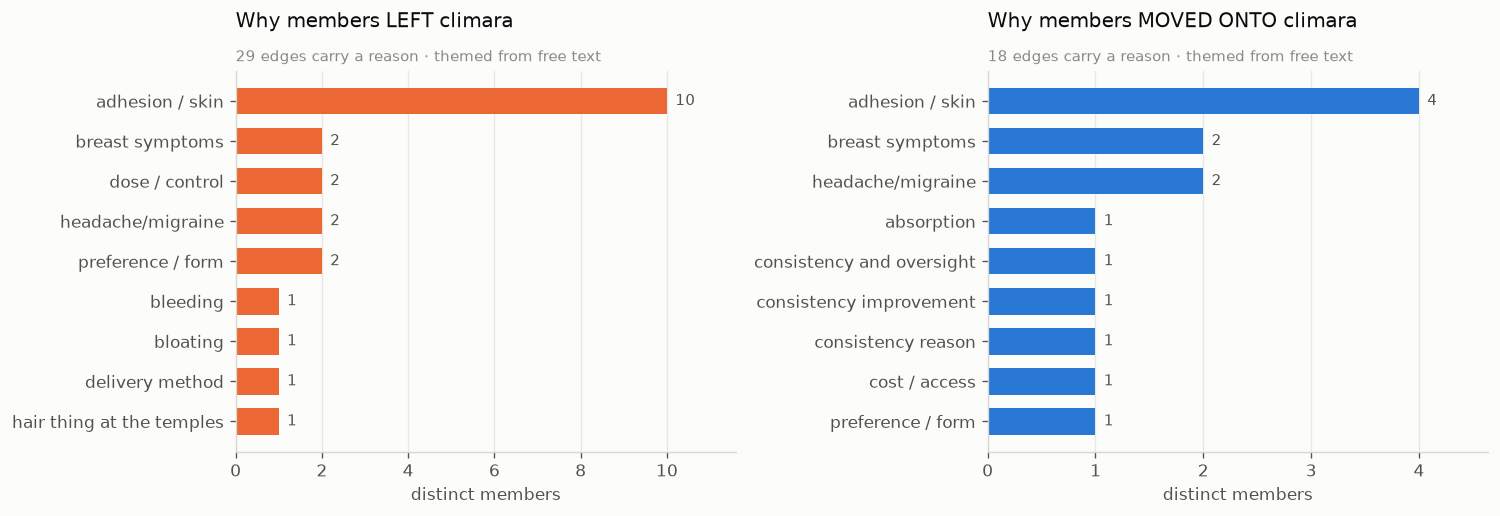

RAW REASONS FOR LEAVING CLIMARA (verbatim, per member)
    4x  adhesion issues
    3x  adhesive issues
    1x  migraines with aura
    1x  progestogen issue
    1x  site_irritation
    1x  hair thing at the temples
    1x  skin irritation
    1x  patch placement
    1x  specifically what i want to know: does gel give more consistent levels or less?
    1x  bloating
    1x  mood swings and brain fog felt worse in the days before patch change
    1x  breast cancer risk conversation

RAW REASONS FOR MOVING ONTO CLIMARA
    3x  adhesion issues
    2x  breast tenderness
    1x  absorption
    1x  reduce first-pass hepatic effects
    1x  side effects
    1x  consistency improvement
    1x  adhesive issues
    1x  gel absorption really does vary person to person and day to day in a way patches don't
    1x  pharmacy out of stock
    1x  migraines


In [10]:

import re

# Free-text reasons folded into themes. Deliberately shallow and visible: anything
# that matches nothing keeps its own words rather than being dropped into "other".
THEMES = [
    ('adhesion / skin',   r'adhes|stick|peel|fall|lift|residue|irritat|rash|itch|welt|hive|skin'),
    ('bleeding',          r'bleed|spot|flood'),
    ('breast symptoms',   r'breast|tender'),
    ('mood',              r'mood|rage|anxiet|depress|irritab'),
    ('headache/migraine', r'migrain|headach|aura'),
    ('dose / control',    r'dose|dosage|absorb|level|titrat|flexib|steady|stable'),
    ('cost / access',     r'cost|price|insur|cover|pharmac|supply|script|afford'),
    ('efficacy',          r'not work|didn.t work|ineffect|no relief|stopped work|not enough'),
    ('clinician advice',  r'doctor|gyn|gp|specialist|advice|recommend|told me'),
    ('preference / form', r'gel|patch|pill|oral|prefer|convenien|easier|simpl'),
]
def theme(r):
    s = str(r).lower()
    for name, pat in THEMES:
        if re.search(pat, s):
            return name
    return s[:40]

def reason_members(df):
    d = df[df.reason.notna()].copy()
    d['theme'] = d.reason.map(theme)
    return d.groupby('theme').author_id.nunique().sort_values(ascending=False).head(9)

ra, rb = reason_members(away), reason_members(onto)

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4), sharex=False)
for ax, s, title, colour, n in (
        (axes[0], ra, f'Why members LEFT {CL}', C2, away.reason.notna().sum()),
        (axes[1], rb, f'Why members MOVED ONTO {CL}', C1, onto.reason.notna().sum())):
    if s.empty:
        ax.axis('off'); tidy(ax, title, 'no stated reasons'); continue
    ax.barh(range(len(s))[::-1], s.values, color=colour, height=0.66)
    ax.set_yticks(range(len(s))[::-1]); ax.set_yticklabels(s.index)
    ax.grid(axis='y', visible=False); ax.margins(x=0.16)
    for i, v in zip(range(len(s))[::-1], s.values):
        ax.annotate(str(int(v)), xy=(v, i), xytext=(5, 0), textcoords='offset points',
                    va='center', color=INK2, fontsize=9)
    ax.set_xlabel('distinct members')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    tidy(ax, title, f'{n} edges carry a reason · themed from free text')
plt.tight_layout(); plt.show()

print(f'RAW REASONS FOR LEAVING {CL.upper()} (verbatim, per member)')
for r, n in (away[away.reason.notna()].drop_duplicates(['author_id', 'reason'])
             .reason.str.strip().str.lower().value_counts().head(12).items()):
    print(f'  {n:>3}x  {r}')
print(f'\nRAW REASONS FOR MOVING ONTO {CL.upper()}')
for r, n in (onto[onto.reason.notna()].drop_duplicates(['author_id', 'reason'])
             .reason.str.strip().str.lower().value_counts().head(10).items()):
    print(f'  {n:>3}x  {r}')


## 5. Receipts — every row traces to the member's own words

`context` is located deterministically in the source text, so it always shows the term in use.
`[in the parent post]` marks a reply discussing a treatment named in the post it answers.


In [11]:
for _, r in mentions[(mentions.canonical_id=='climara')].head(6).iterrows():
    print(f"{r.doc_id}  {r.author_id}  stance={r.stance}  by={r.experienced_by}")
    print(f"  surface: {r.surface!r}")
    for line in textwrap.wrap(str(r.context or '(no context)'), 96, initial_indent='  ', subsequent_indent='  ')[:3]:
        print(line)
    print()


reply_f1ea8f7c3d0b  user_031  stance=current  by=self
  surface: 'Climara patch'
  …I'm not going to offer anything except — yes. This is grief and it's real and it deserves to
  be called what it is. I'm on the Climara patch now and it's helped the rage a bit but it
  hasn't fixed the feeling of being a stranger to myself, so I know that part isn't just…

reply_b3b0c2be9be8  user_056  stance=current  by=general
  surface: 'Climara patch'
  …they faded around weeks 6-10. That said, I had to stop HRT myself because of breast
  tenderness so I can't give you a personal patch success story — but from everything I've read,
  your gyno telling you to wait it out is actually pretty standard advice.

reply_1b22ae455e84  user_086  stance=current  by=self
  surface: 'Climara patch'
  I made exactly this transition about two years ago — Vagifem plus added Climara patch, and
  then Prometrium. First month: breast tenderness yes, quite noticeable, lasted roughly six
  weeks for me. Bloating was a…

## 6. Landscape — what else members are on

Ranked by distinct members with a self-reported mention, which is the number that matters
for share-of-patient questions (mention counts over-weight the few heaviest posters).


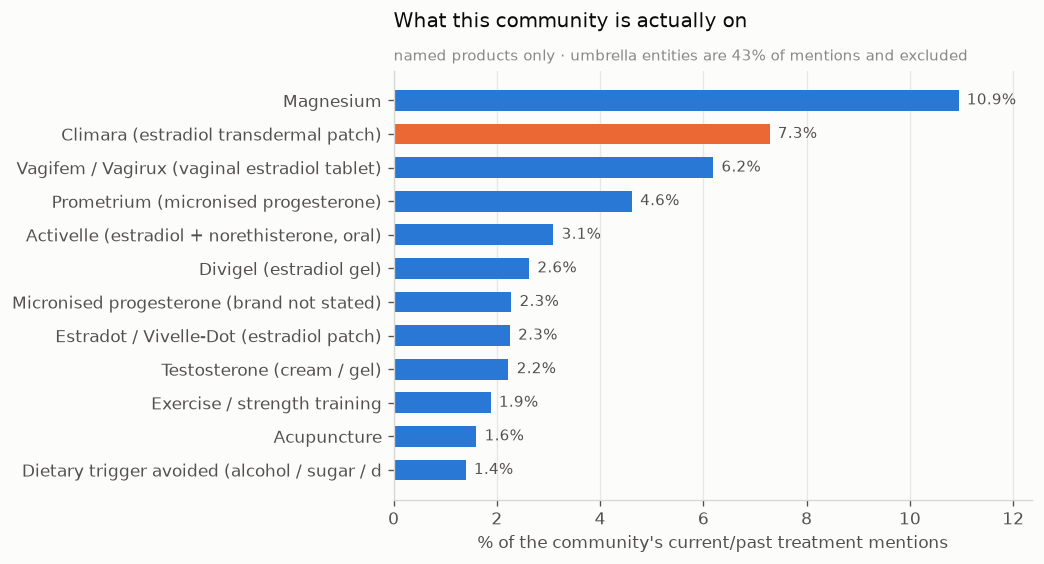

In [12]:
# FIXED: this ranked treatments by "members with a self-reported mention", which
# saturates - 69 to 100 of 100 members for everything common, so every bar sat near
# the maximum and the products could not be told apart.
#
# Share of the community's current/past treatment mentions does separate them.
use = self_tx[self_tx.stance.isin(['current', 'past'])
              & self_tx.canonical_id.notna()
              & (self_tx.canonical_id != 'non_entity')]
UMBRELLA = [c for c in use.canonical_id.unique()
            if c.endswith(('_unspecified', '_generic')) or c == 'dose_change']

named = use[~use.canonical_id.isin(UMBRELLA)]
land = (named.canonical_id.value_counts() / len(use)).head(12)
labels_map = summary.set_index('canonical_id').label.to_dict()

fig, ax = plt.subplots(figsize=(8.8, 4.8))
names = [labels_map.get(i, i)[:44] for i in land.index][::-1]
vals  = land.values[::-1] * 100
cols  = [C2 if i == 'climara' else C1 for i in land.index][::-1]
ax.barh(names, vals, color=cols, height=0.62)
ax.margins(x=0.13)
for i, v in enumerate(vals):
    ax.annotate(f'{v:.1f}%', xy=(v, i), xytext=(5, 0), textcoords='offset points',
                va='center', color=INK2, fontsize=9)
ax.grid(axis='y', visible=False)
ax.set_xlabel("% of the community's current/past treatment mentions")
tidy(ax, 'What this community is actually on',
     f'named products only · umbrella entities are '
     f'{100*len(use[use.canonical_id.isin(UMBRELLA)])/len(use):.0f}% of mentions and excluded')
plt.tight_layout(); plt.show()

## 7. Caveats to carry into the meeting

- **Synthetic corpus.** Generated from ~100 personas; useful for method, not for market sizing.
- **`race_ethnicity` is not a reportable cut.** Recorded only when explicitly self-stated
  (~5-10% of members) and never inferred. At that fill rate any slice is both statistically
  meaningless and re-identifying in a community this small.
- **Professions are conservative.** A claim is rejected unless it appears in the text, so
  reasonable inferences (`surgeon` from "I can't do certain procedures") are dropped. The
  rejects are kept in `demographic_claims` with a reason — the precision/coverage trade is
  reversible.
- **Menopause stage is not extracted.** The plan called for it; the schema never carried it.
  It is absent rather than guessed.
